# Нейросетевая классификация патологий ритма сердца

Этот ноутбук обучает и применяет **1D-CNN (ResNet) модель** для классификации сердечных сокращений по стандарту AAMI. Список классов берётся из файла данных (например: N, S, V, F).

## Как пользоваться (проверка модели)

1. Выполните все ячейки по порядку (**Runtime → Run all** или Ctrl+F9).
2. В **последней ячейке** запустится функция `main_test()`:
   - введите путь к вашему файлу с данными (в Google Colab можно просто нажать Enter и выбрать файл через диалог загрузки);
   - ноутбук выполнит предобработку, предсказание и выведет понятный результат.
3. Поддерживаемые форматы файлов:
   - `.npz` — с ключами `X` (сигналы, форма `(N, 250)`) и опционально `rr` (RR-признаки, форма `(N, 6)`);
   - `.npy` — массив сигналов `(N, 250)`;
   - `.csv` — столбцы 0–249 сигнал, 250–255 RR-признаки (опционально).

## Как переобучить модель (опционально)

Раскомментируйте вызов `run_training_pipeline(...)` в соответствующей ячейке ниже.

## Структура файлов

Все файлы должны лежать **в одной папке с ноутбуком**:
- `mitbih_balanced.npz` — данные для обучения;
- `my_ecg.npz` — данные для теста;
- `best_ecg_model.pth` — чекпоинт лучшей модели (создаётся при обучении);
- `ecg_model_final.pth` — финальная модель для инференса (создаётся при обучении).

## 0. Установка зависимостей

Раскомментируйте при необходимости (например, в Colab).

In [93]:
# !pip install torch numpy matplotlib scikit-learn seaborn

## 1. Импорты и вспомогательные функции

In [116]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report,
    f1_score, precision_score, recall_score, accuracy_score
)
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau


def set_seed(seed=42):
    """Фиксирует seed для воспроизводимости."""
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def get_device():
    """Возвращает устройство вычислений (GPU при наличии, иначе CPU)."""
    return torch.device('cuda' if torch.cuda.is_available() else 'cpu')


set_seed(42)
print('Библиотеки загружены. Устройство по умолчанию:', get_device())

Библиотеки загружены. Устройство по умолчанию: cpu


## 2. Пути по умолчанию

Все файлы лежат в одной папке с ноутбуком. Каждая функция принимает пути как параметры со значениями по умолчанию.

In [117]:
DATA_PATH = 'mitbih_balanced.npz'         # данные (обучение/тест)
BEST_MODEL_PATH = 'best_ecg_model.pth'    # чекпоинт обучения (создаётся при обучении)
FINAL_MODEL_PATH = 'ecg_model_final.pth'  # финальная модель для инференса (создаётся при обучении)

## 3. Загрузка файла данных

In [118]:
def load_data(data_path=DATA_PATH):
    """Загружает npz-файл с данными. Возвращает dict {ключ: массив}."""
    if not os.path.exists(data_path):
        raise FileNotFoundError(
            f'Файл данных не найден: {data_path}. '
            'Положите его в папку с ноутбуком или укажите другой путь.'
        )
    with np.load(data_path, allow_pickle=True) as npz:
        return {key: npz[key] for key in npz.files}

## 4. Очистка данных 

In [119]:
def clean_data(raw, rr_clip=6.0):
    """
    Очистка сырых данных:
    - удаление строк с NaN (в сигналах и RR-признаках);
    - клиппинг RR-признаков (±rr_clip — экстремальные значения);
    - приведение типов.
    Принимает dict сырых данных, возвращает dict чистых.
    """
    cleaned = {}
    for key, arr in raw.items():
        arr = np.asarray(arr)
        if arr.ndim == 0:
            cleaned[key] = arr
            continue
        if key.endswith('_rr'):
            arr = np.clip(arr.astype(np.float32), -rr_clip, rr_clip)
        elif key.startswith('X_'):
            arr = arr.astype(np.float32)
        cleaned[key] = arr

    for base in ('X_train', 'X_val', 'X_test'):
        if base not in cleaned:
            continue
        y_key = base.replace('X_', 'y_')
        rr_key = base + '_rr'
        mask = ~np.isnan(cleaned[base]).any(axis=1)
        if rr_key in cleaned:
            mask &= ~np.isnan(cleaned[rr_key]).any(axis=1)
        cleaned[base] = cleaned[base][mask]
        if y_key in cleaned:
            cleaned[y_key] = cleaned[y_key][mask]
        if rr_key in cleaned:
            cleaned[rr_key] = cleaned[rr_key][mask]
    return cleaned

## 5. Предобработка данных

Стратегии балансировки: `'weighted'` (несбалансированный train + взвешенный loss), `'smote'`, `'augment'`.

In [120]:
def preprocess_data(cleaned, strategy='weighted', max_weight_ratio=10.0, device=None):
    """
    Предобработка чистых данных:
    - выбирает обучающие массивы по стратегии ('weighted' | 'smote' | 'augment');
    - считает веса классов для взвешенного loss (стратегия 'weighted');
    - считает статистику RR по train (нужна для согласованного инференса).
    Возвращает dict, готовый к созданию DataLoader'ов.
    """
    device = device or get_device()
    class_names = list(cleaned['class_names'])

    if strategy == 'smote':
        x_train, y_train, rr_train = (cleaned['X_train_smote'],
                                      cleaned['y_train_smote'],
                                      cleaned['X_train_smote_rr'])
        use_weighted_loss = False
    elif strategy == 'augment':
        x_train, y_train, rr_train = (cleaned['X_train_aug'],
                                      cleaned['y_train_aug'],
                                      cleaned['X_train_aug_rr'])
        use_weighted_loss = False
    else:  # 'weighted'
        x_train, y_train, rr_train = (cleaned['X_train'],
                                      cleaned['y_train'],
                                      cleaned['X_train_rr'])
        use_weighted_loss = True

    class_weights = None
    if use_weighted_loss:
        classes = np.unique(y_train)
        counts = np.array([np.sum(y_train == c) for c in classes], dtype=np.float64)
        w = len(y_train) / (len(classes) * counts)
        w = w / w.mean()
        w = np.clip(w, w.max() / max_weight_ratio, None)
        w = w / w.mean()
        class_weights = torch.tensor(w, dtype=torch.float32, device=device)

    # RR в данных уже z-score; пересчёт по train безопасен и нужен для инференса
    rr_mean = rr_train.mean(axis=0)
    rr_std = rr_train.std(axis=0) + 1e-8

    return {
        'X_train': x_train, 'y_train': y_train, 'rr_train': rr_train,
        'X_val': cleaned['X_val'], 'y_val': cleaned['y_val'], 'rr_val': cleaned['X_val_rr'],
        'X_test': cleaned['X_test'], 'y_test': cleaned['y_test'], 'rr_test': cleaned['X_test_rr'],
        'class_weights': class_weights, 'use_weighted_loss': use_weighted_loss,
        'class_names': class_names, 'n_classes': len(class_names),
        'rr_mean': rr_mean, 'rr_std': rr_std, 'strategy': strategy,
    }

In [121]:
def summarize_data(prepared):
    """Печатает краткую сводку по сплитам, классам и весам."""
    k = prepared['n_classes']
    bc = lambda y: np.bincount(y, minlength=k)
    print(f"Классы: {prepared['class_names']} | стратегия: {prepared['strategy']}")
    print(f"Train: {prepared['X_train'].shape} {bc(prepared['y_train'])}")
    print(f"Val:   {prepared['X_val'].shape} {bc(prepared['y_val'])}")
    print(f"Test:  {prepared['X_test'].shape} {bc(prepared['y_test'])}")
    if prepared['class_weights'] is not None:
        print('Веса в loss:', prepared['class_weights'].detach().cpu().numpy().round(3))

## 6. Dataset и создание DataLoader

In [122]:
class ECGDataset(Dataset):
    """Dataset ЭКГ-сегментов: сигнал (1, T), RR-вектор, метка."""

    def __init__(self, X, rr, y):
        self.X = torch.from_numpy(np.asarray(X, dtype=np.float32)).unsqueeze(1)
        self.rr = torch.from_numpy(np.asarray(rr, dtype=np.float32))
        self.y = torch.from_numpy(np.asarray(y, dtype=np.int64))

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.rr[idx], self.y[idx]


def create_loaders(prepared, batch_size=256):
    """Создаёт DataLoader'ы из предобработанных данных."""
    train_ds = ECGDataset(prepared['X_train'], prepared['rr_train'], prepared['y_train'])
    val_ds = ECGDataset(prepared['X_val'], prepared['rr_val'], prepared['y_val'])
    test_ds = ECGDataset(prepared['X_test'], prepared['rr_test'], prepared['y_test'])
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=0)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0)
    return train_loader, val_loader, test_loader

## 7. Архитектура модели: 1D ResNet

Residual-связи $y = F(x) + x$ стабилизируют обучение; свёртки извлекают локальные морфологические признаки QRS-комплекса, MLP-ветка обрабатывает RR-интервалы.

In [123]:
class ResidualBlock1D(nn.Module):
    """Residual-блок: y = F(x) + shortcut(x)."""

    def __init__(self, in_channels, out_channels, kernel_size=5, stride=1, dropout=0.2):
        super().__init__()
        padding = kernel_size // 2
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size,
                               stride=stride, padding=padding, bias=False)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size,
                               stride=1, padding=padding, bias=False)
        self.bn2 = nn.BatchNorm1d(out_channels)
        self.dropout = nn.Dropout(dropout)
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, 1, stride=stride, bias=False),
                nn.BatchNorm1d(out_channels)
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        identity = self.shortcut(x)
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.dropout(out)
        out = self.bn2(self.conv2(out))
        out = out + identity
        return F.relu(out)


class ECGResNet(nn.Module):
    """
    1D ResNet для классификации ЭКГ-сегментов с RR-признаками.
    Две ветки: свёрточная (сигнал) + MLP (RR), затем слияние и классификатор.
    """

    def __init__(self, n_classes=4, rr_features=6, base_channels=32, dropout=0.3):
        super().__init__()
        # --- Ветка 1: сигнал ---
        self.stem = nn.Sequential(
            nn.Conv1d(1, base_channels, kernel_size=7, stride=1, padding=3, bias=False),
            nn.BatchNorm1d(base_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(2),  # 250 -> 125
        )
        self.block1 = ResidualBlock1D(base_channels, base_channels, stride=1, dropout=0.2)
        self.block2 = ResidualBlock1D(base_channels, base_channels * 2, stride=2, dropout=0.2)
        self.block3 = ResidualBlock1D(base_channels * 2, base_channels * 4, stride=2, dropout=0.3)
        self.gap = nn.AdaptiveAvgPool1d(1)
        # --- Ветка 2: RR-признаки ---
        rr_hidden = 32
        self.rr_branch = nn.Sequential(
            nn.Linear(rr_features, rr_hidden),
            nn.BatchNorm1d(rr_hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
        )
        # --- Классификатор ---
        fused_dim = base_channels * 4 + rr_hidden
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(fused_dim, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(64, n_classes)
        )

    def forward(self, x, rr):
        x = self.stem(x)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.gap(x)
        x = torch.flatten(x, 1)
        r = self.rr_branch(rr)
        z = torch.cat([x, r], dim=1)
        return self.classifier(z)


def count_parameters(model):
    """Возвращает число обучаемых параметров модели."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

## 8. Получение модели

In [129]:
def get_model(n_classes, rr_features, model_path=BEST_MODEL_PATH, preload=True,
              base_channels=32, dropout=0.3, device=None):
    """
    Создаёт ECGResNet. Если preload=True и файл существует — загружает веса.
    Возвращает (model, checkpoint или None).
    """
    device = device or get_device()
    model = ECGResNet(n_classes=n_classes, rr_features=rr_features,
                      base_channels=base_channels, dropout=dropout).to(device)
    checkpoint = None
    if preload and os.path.exists(model_path):
        checkpoint = torch.load(model_path, map_location=device, weights_only=False)
        model.load_state_dict(checkpoint['model_state_dict'])
        print(f"Загружена модель из {model_path} "
              f"(эпоха {checkpoint.get('epoch')}, val F1 = {checkpoint.get('val_f1', 0):.4f})")
    elif preload:
        print(f'Файл {model_path} не найден — модель будет обучена с нуля.')
    print(f'Параметров в модели: {count_parameters(model):,}')
    return model, checkpoint

## 9. Функция потерь

In [130]:
class FocalLoss(nn.Module):
    """Focal Loss (gamma=2): гасит вклад уверенных примеров, усиливает трудные."""

    def __init__(self, gamma=2.0, weight=None):
        super().__init__()
        self.gamma = gamma
        self.weight = weight

    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, weight=self.weight, reduction='none')
        pt = torch.exp(-ce)
        return ((1 - pt) ** self.gamma * ce).mean()


def get_criterion(use_weighted_loss=True, class_weights=None):
    """Возвращает функцию потерь (Focal с весами или обычный CrossEntropy)."""
    if use_weighted_loss and class_weights is not None:
        return FocalLoss(gamma=2.0, weight=class_weights)
    return nn.CrossEntropyLoss()

## 10. Функции обучения и валидации

In [131]:
def train_epoch(model, loader, criterion, optimizer, device):
    """Одна эпоха обучения. Возвращает (loss, accuracy, macro-F1)."""
    model.train()
    total_loss = 0.0
    all_preds, all_labels = [], []
    for x, rr, y in loader:
        x, rr, y = x.to(device), rr.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x, rr)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        all_preds.append(logits.argmax(dim=1).cpu().numpy())
        all_labels.append(y.cpu().numpy())
    avg_loss = total_loss / len(loader.dataset)
    preds = np.concatenate(all_preds)
    labels = np.concatenate(all_labels)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average='macro', zero_division=0)
    return avg_loss, acc, f1


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """Оценка модели на выборке. Возвращает (loss, accuracy, macro-F1, preds, labels)."""
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []
    for x, rr, y in loader:
        x, rr, y = x.to(device), rr.to(device), y.to(device)
        logits = model(x, rr)
        loss = criterion(logits, y)
        total_loss += loss.item() * x.size(0)
        all_preds.append(logits.argmax(dim=1).cpu().numpy())
        all_labels.append(y.cpu().numpy())
    avg_loss = total_loss / len(loader.dataset)
    preds = np.concatenate(all_preds)
    labels = np.concatenate(all_labels)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average='macro', zero_division=0)
    return avg_loss, acc, f1, preds, labels

## 11. Обучение модели 

Early Stopping по macro-F1 на валидации: при дисбалансе классов macro-F1 — более честная метрика, чем accuracy.

In [132]:
def train_model(model, train_loader, val_loader, criterion, device,
                preloaded=False, strategy='weighted',
                n_epochs=30, patience=4, min_delta=1e-3,
                lr=1e-3, weight_decay=1e-4, best_model_path=BEST_MODEL_PATH):
    """
    Обучает модель с Early Stopping по macro-F1 на валидации.
    Если preloaded=True — обучение пропускается.
    Возвращает history (или None, если обучение пропущено).
    """
    if preloaded:
        print('Модель предзагружена — обучение пропущено.')
        return None

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [],
               'train_f1': [], 'val_f1': [], 'lr': []}
    best_val_f1, epochs_no_improve = 0.0, 0

    for epoch in range(1, n_epochs + 1):
        train_loss, train_acc, train_f1 = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc, val_f1, _, _ = evaluate(model, val_loader, criterion, device)
        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]['lr']

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['train_f1'].append(train_f1)
        history['val_f1'].append(val_f1)
        history['lr'].append(current_lr)

        marker = ''
        if val_f1 > best_val_f1 + min_delta:
            best_val_f1, epochs_no_improve = val_f1, 0
            torch.save({'epoch': epoch, 'strategy': strategy,
                        'model_state_dict': model.state_dict(),
                        'optimizer_state_dict': optimizer.state_dict(),
                        'val_f1': val_f1, 'val_acc': val_acc}, best_model_path)
            marker = ' ★ (saved)'
        else:
            epochs_no_improve += 1

        print(f'Эпоха {epoch:3d}/{n_epochs} | '
              f'Train loss={train_loss:.4f} acc={train_acc:.4f} f1={train_f1:.4f} | '
              f'Val loss={val_loss:.4f} acc={val_acc:.4f} f1={val_f1:.4f} | '
              f'lr={current_lr:.1e}{marker}')

        if epochs_no_improve >= patience:
            print(f'⚠ Early stopping: F1 не улучшался {patience} эпох подряд')
            break

    print(f'✓ Обучение завершено. Лучший val F1 = {best_val_f1:.4f}')
    return history

## 12. Графики обучения

In [127]:
def plot_history(history):
    """Рисует графики loss / accuracy / macro-F1 по history обучения."""
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    epochs = range(1, len(history['train_loss']) + 1)
    for ax, key, title in zip(axes, ['loss', 'acc', 'f1'],
                              ['Функция потерь', 'Точность', 'Macro F1-score']):
        ax.plot(epochs, history[f'train_{key}'], 'o-', label='Train', color='steelblue')
        ax.plot(epochs, history[f'val_{key}'], 's-', label='Val', color='coral')
        ax.set_xlabel('Эпоха')
        ax.set_title(title)
        ax.legend()
        ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## 13. Оценка на тесте и визуализация

In [128]:
def test_model(model, test_loader, criterion, device, class_names):
    """Оценивает модель на тесте, печатает отчёт. Возвращает (metrics, preds, labels)."""
    loss, acc, f1, preds, labels = evaluate(model, test_loader, criterion, device)
    print(f'Test loss: {loss:.4f} | Accuracy: {acc:.4f} | Macro F1: {f1:.4f}')
    print(classification_report(labels, preds, target_names=class_names,
                                digits=4, zero_division=0))
    return {'loss': loss, 'accuracy': acc, 'macro_f1': f1}, preds, labels


def plot_confusion(y_true, y_pred, class_names):
    """Строит confusion matrix (абсолютную и нормализованную по строкам)."""
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names,
                yticklabels=class_names, ax=axes[0])
    axes[0].set_title('Confusion Matrix (абсолютные)')
    sns.heatmap(cm_norm, annot=True, fmt='.3f', cmap='Greens', xticklabels=class_names,
                yticklabels=class_names, ax=axes[1], vmin=0, vmax=1)
    axes[1].set_title('Confusion Matrix (доли по классу)')
    for ax in axes:
        ax.set_xlabel('Предсказано')
        ax.set_ylabel('Истинный класс')
    plt.tight_layout()
    plt.show()


def plot_predictions(X, y_true, y_pred, class_names, n_per_class=2):
    """Показывает примеры верных (зелёные) и ошибочных (красные) предсказаний."""
    n_classes = len(class_names)
    fig, axes = plt.subplots(n_classes, n_per_class * 2, figsize=(16, 3 * n_classes))
    for cls_idx, cls_name in enumerate(class_names):
        correct = np.where((y_true == cls_idx) & (y_pred == cls_idx))[0]
        wrong = np.where((y_true == cls_idx) & (y_pred != cls_idx))[0]
        for j in range(n_per_class * 2):
            ax = axes[cls_idx, j]
            pool, ok = (correct, True) if j < n_per_class else (wrong, False)
            jj = j if ok else j - n_per_class
            if len(pool) > jj:
                idx = pool[jj]
                ax.plot(X[idx].squeeze(), color='green' if ok else 'red', linewidth=1)
                mark = '✓' if ok else '✗'
                ax.set_title(f'{mark} {cls_name} -> {class_names[y_pred[idx]]}',
                             fontsize=9, color='darkgreen' if ok else 'darkred')
            ax.grid(alpha=0.3)
            ax.set_xticks([])
    plt.suptitle('Примеры предсказаний (зелёные — верно, красные — ошибки)', y=1.00)
    plt.tight_layout()
    plt.show()

## 14. Сохранение финальной модели

In [108]:
def save_final_model(model, prepared, history, test_metrics,
                     model_path=FINAL_MODEL_PATH, rr_clip=6.0,
                     base_channels=32, dropout=0.3):
    """Сохраняет модель + всё, что нужно для инференса (включая статистику RR)."""
    torch.save({
        'model_state_dict': model.state_dict(),
        'model_class': 'ECGResNet',
        'model_config': {'n_classes': prepared['n_classes'],
                         'rr_features': prepared['rr_train'].shape[1],
                         'base_channels': base_channels, 'dropout': dropout},
        'class_names': prepared['class_names'],
        'rr_mean': prepared['rr_mean'], 'rr_std': prepared['rr_std'], 'rr_clip': rr_clip,
        'strategy': prepared['strategy'],
        'test_metrics': test_metrics,
        'history': history,
    }, model_path)
    print(f'✓ Модель сохранена в {model_path}')

## 15. Главная функция обучения

Запускает весь пайплайн: загрузка → очистка → предобработка → loaders → модель → обучение → графики → оценка → сохранение.

In [109]:
def run_training_pipeline(data_path=DATA_PATH, best_model_path=BEST_MODEL_PATH,
                          final_model_path=FINAL_MODEL_PATH, preload=False,
                          strategy='weighted', batch_size=256, n_epochs=30,
                          patience=4, min_delta=1e-3, device=None):
    """
    Полный пайплайн: загрузка → очистка → предобработка → loaders →
    модель → обучение → графики → оценка → сохранение.
    preload=True — пропустить обучение и использовать существующий чекпоинт.
    """
    device = device or get_device()
    print(f'Устройство: {device}')
    raw = load_data(data_path)                                                    # a. загрузка
    cleaned = clean_data(raw)                                                     # b. очистка
    prepared = preprocess_data(cleaned, strategy=strategy, device=device)         # c. предобработка
    summarize_data(prepared)
    train_loader, val_loader, test_loader = create_loaders(prepared, batch_size)  # d. loaders
    model, ckpt = get_model(prepared['n_classes'], prepared['rr_train'].shape[1],
                            model_path=best_model_path, preload=preload, device=device)  # e. модель
    criterion = get_criterion(prepared['use_weighted_loss'], prepared['class_weights'])
    history = train_model(model, train_loader, val_loader, criterion, device,
                          preloaded=preload and ckpt is not None,
                          strategy=strategy, n_epochs=n_epochs,
                          patience=patience, min_delta=min_delta,
                          best_model_path=best_model_path)                        # f. обучение
    if history is not None:
        plot_history(history)                                                     # g. графики
        best = torch.load(best_model_path, map_location=device, weights_only=False)
        model.load_state_dict(best['model_state_dict'])
    metrics, preds, labels = test_model(model, test_loader, criterion, device,
                                        prepared['class_names'])                  # h. оценка
    plot_confusion(labels, preds, prepared['class_names'])
    plot_predictions(prepared['X_test'], labels, preds, prepared['class_names'])
    save_final_model(model, prepared, history, metrics, final_model_path)
    return {'model': model, 'prepared': prepared, 'history': history, 'metrics': metrics}

## 16. Запуск обучения (опционально)

Если нужно **переобучить модель**, раскомментируйте строку ниже. Для простой проверки обученной модели переходите сразу к последней ячейке.

Устройство: cpu
Классы: ['N', 'S', 'V', 'F'] | стратегия: weighted
Train: (44911, 250) [40725   733  3058   395]
Val:   (6082, 250) [5122  211  730   19]
Test:  (49684, 250) [44239  1837  3220   388]
Веса в loss: [0.226 1.219 0.292 2.262]
Параметров в модели: 186,500
Эпоха   1/30 | Train loss=0.0178 acc=0.8228 f1=0.5110 | Val loss=0.0807 acc=0.7442 f1=0.3553 | lr=1.0e-03 ★ (saved)
Эпоха   2/30 | Train loss=0.0085 acc=0.9072 f1=0.6191 | Val loss=0.0949 acc=0.6906 f1=0.3766 | lr=1.0e-03 ★ (saved)
Эпоха   3/30 | Train loss=0.0079 acc=0.9179 f1=0.6376 | Val loss=0.0985 acc=0.7693 f1=0.3116 | lr=1.0e-03
Эпоха   4/30 | Train loss=0.0067 acc=0.9228 f1=0.6484 | Val loss=0.0988 acc=0.6013 f1=0.3395 | lr=1.0e-03
Эпоха   5/30 | Train loss=0.0057 acc=0.9313 f1=0.6683 | Val loss=0.0977 acc=0.6702 f1=0.3661 | lr=5.0e-04
Эпоха   6/30 | Train loss=0.0050 acc=0.9380 f1=0.6879 | Val loss=0.1061 acc=0.6809 f1=0.3802 | lr=5.0e-04 ★ (saved)
Эпоха   7/30 | Train loss=0.0044 acc=0.9435 f1=0.7015 | Val loss=0

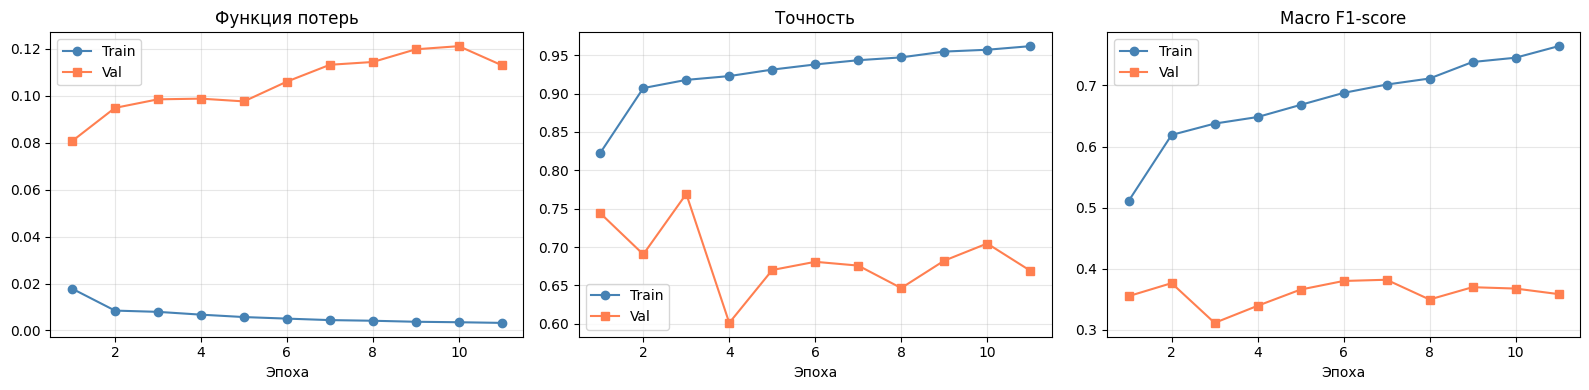

Test loss: 0.0410 | Accuracy: 0.8201 | Macro F1: 0.6014
              precision    recall  f1-score   support

           N     0.9857    0.8222    0.8966     44239
           S     0.4625    0.7746    0.5792      1837
           V     0.9187    0.8842    0.9011      3220
           F     0.0151    0.2577    0.0286       388

    accuracy                         0.8201     49684
   macro avg     0.5955    0.6847    0.6014     49684
weighted avg     0.9544    0.8201    0.8783     49684



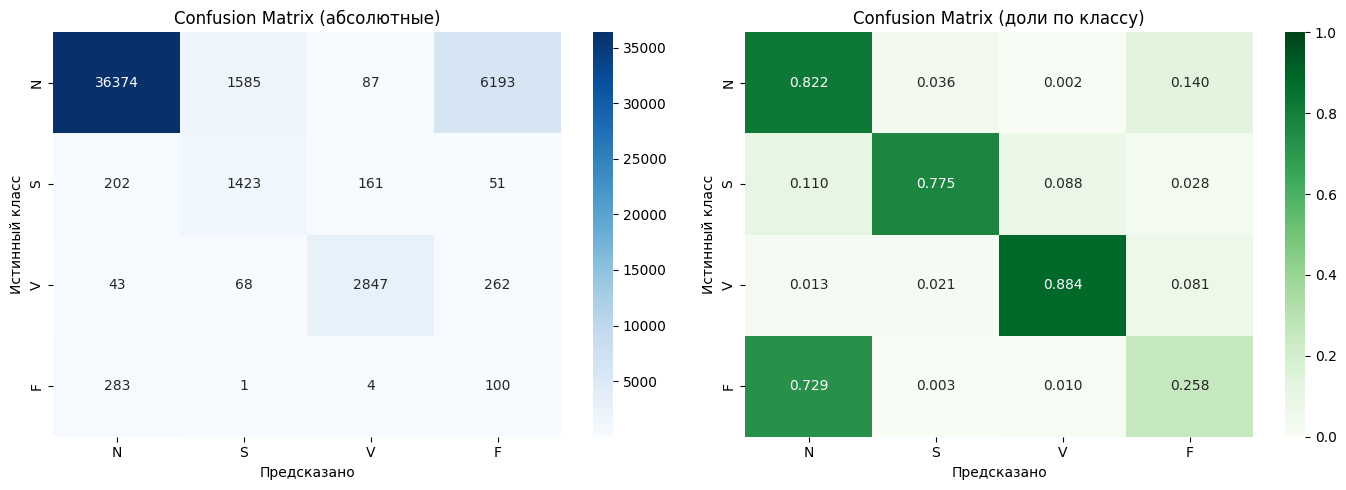

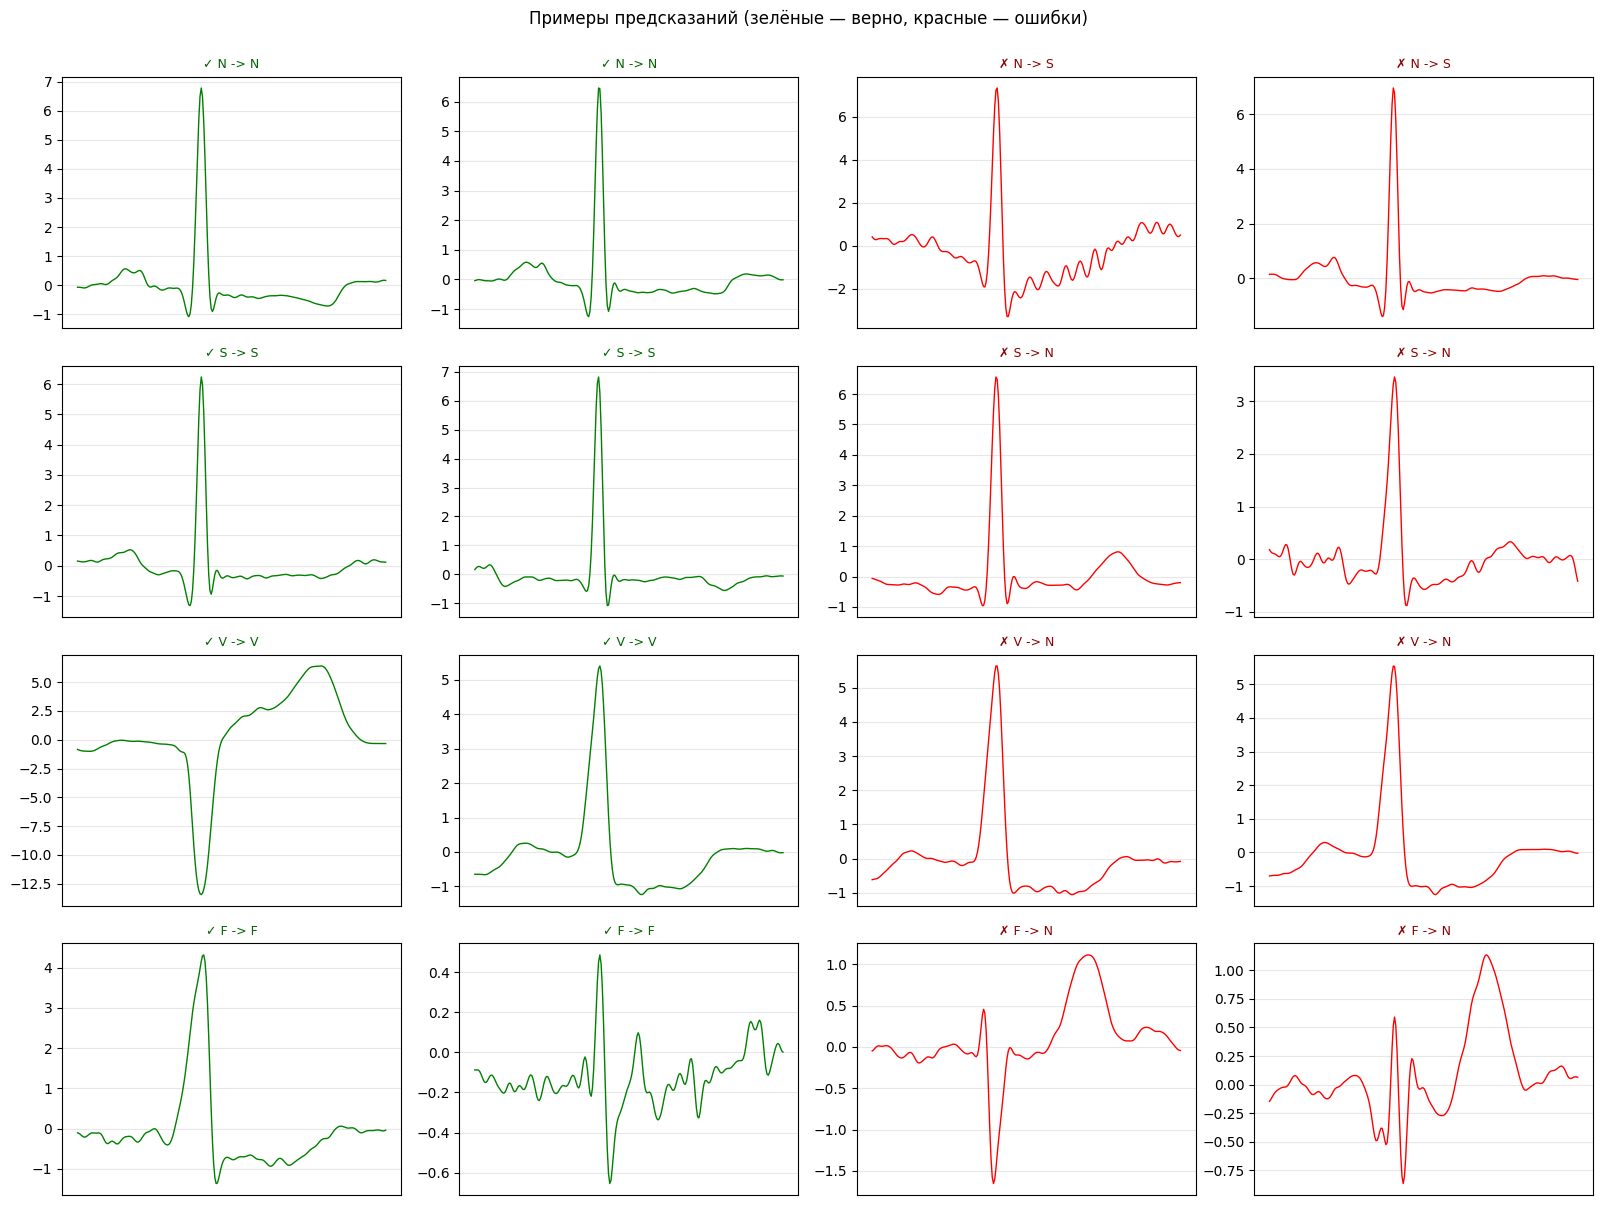

✓ Модель сохранена в ecg_model_final.pth


In [ ]:
# artifacts = run_training_pipeline(preload=False, strategy='weighted')

## 17. Функции инференса (предсказание для пользователя)

In [133]:
def load_inference_model(model_path=FINAL_MODEL_PATH, device=None):
    """Загружает финальную модель и метаинформацию для инференса."""
    device = device or get_device()
    if not os.path.exists(model_path):
        raise FileNotFoundError(
            f'Файл модели не найден: {model_path}. Положите его в папку с ноутбуком.')
    ckpt = torch.load(model_path, map_location=device, weights_only=False)

    # Совместимость со старыми чекпоинтами: дефолты для отсутствующих ключей
    class_names = list(ckpt.get('class_names', ['N', 'S', 'V', 'F']))
    cfg = dict(ckpt.get('model_config', {}))
    cfg.setdefault('n_classes', len(class_names))
    cfg.setdefault('rr_features', 6)      # в данных MIT-BIH всегда 6 RR-признаков
    cfg.setdefault('base_channels', 32)
    cfg.setdefault('dropout', 0.3)
    if 'rr_features' in ckpt:             # ключ мог лежать рядом с model_config
        cfg['rr_features'] = ckpt['rr_features']

    model = ECGResNet(**cfg).to(device)
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()

    meta = {
        'class_names': class_names,
        'rr_mean': np.asarray(ckpt['rr_mean']) if 'rr_mean' in ckpt else np.zeros(cfg['rr_features']),
        'rr_std': np.asarray(ckpt['rr_std']) if 'rr_std' in ckpt else np.ones(cfg['rr_features']),
        'rr_clip': float(ckpt.get('rr_clip', 6.0)),
        'test_metrics': ckpt.get('test_metrics'),
    }
    if 'rr_mean' not in ckpt:
        print('⚠ В файле модели нет статистики RR — используются значения по умолчанию '
              '(переобучите и пересохраните модель для полной точности).')
    return model, meta


def preprocess_input(signals, rr=None, rr_mean=None, rr_std=None, rr_clip=6.0, target_len=250):
    """Предобработка пользовательского сигнала под формат модели."""
    X = np.asarray(signals, dtype=np.float32)
    if X.ndim == 1:
        X = X[None, :]
    if X.shape[1] != target_len:
        raise ValueError(f'Ожидается длина сегмента {target_len} отсчётов, получено {X.shape[1]}')
    if rr is None:
        rr = np.zeros((X.shape[0], len(rr_mean)), dtype=np.float32)
        print('⚠ RR-признаки не переданы — используются средние значения '
              '(точность может снизиться).')
    rr = np.asarray(rr, dtype=np.float32)
    if rr.ndim == 1:
        rr = rr[None, :]
    rr = np.clip((rr - rr_mean) / rr_std, -rr_clip, rr_clip)
    # страховка: нормализация float64-статистикой повышает dtype до float64
    return X.astype(np.float32), rr.astype(np.float32)


def predict_signals(model, X, rr, device=None):
    """Предсказание модели: возвращает (классы, вероятности)."""
    device = device or get_device()
    model.eval()
    with torch.no_grad():
        logits = model(torch.from_numpy(np.asarray(X, dtype=np.float32)).unsqueeze(1).to(device),
                       torch.from_numpy(np.asarray(rr, dtype=np.float32)).to(device))
        probs = torch.softmax(logits, dim=1).cpu().numpy()
    return probs.argmax(axis=1), probs


def interpret_predictions(preds, probs, class_names, descriptions=None):
    """Постобработка: формирует понятный текстовый вывод."""
    if descriptions is None:
        descriptions = {
            'N': 'нормальный сердечный комплекс — патологии ритма не выявлено',
            'S': 'наджелудочковая экстрасистола (обычно доброкачественная; '
                 'при частом повторении нужен контроль)',
            'V': 'желудочковая экстрасистола (требует внимания, особенно при повторении)',
            'F': 'сливной (фьюжн) комплекс — редкий класс, рекомендуется проверка специалистом',
            'Q': 'артефакт/неизвестный тип — не поддаётся классификации',
        }
    lines = ['=' * 60, 'РЕЗУЛЬТАТ АНАЛИЗА ЭКГ', '=' * 60]
    for i, (pred, prob) in enumerate(zip(preds, probs)):
        name = class_names[pred]
        conf = float(prob[pred])
        level = 'высокая' if conf >= 0.8 else ('средняя' if conf >= 0.5 else 'низкая')
        top2 = np.argsort(prob)[::-1][:2]
        lines.append(f'Сегмент {i + 1}: класс «{name}» — {descriptions.get(name, "")}')
        lines.append(f'  Уверенность: {conf:.1%} ({level})')
        lines.append('  Вероятности: ' + ', '.join(f'{class_names[j]}={prob[j]:.1%}' for j in top2))
    lines.append('-' * 60)
    lines.append('⚠ Результат носит справочный характер и не является медицинским диагнозом.')
    return '\n'.join(lines)

In [112]:
def ask_file_path():
    """Спрашивает путь к файлу; в Google Colab предлагает загрузку через диалог."""
    try:
        from google.colab import files as colab_files
        answer = input('Введите путь к файлу или оставьте пустым для загрузки с компьютера: ').strip()
        if not answer:
            print('Выберите файл...')
            uploaded = colab_files.upload()
            answer = next(iter(uploaded))
        return answer
    except ImportError:
        return input('Введите путь к файлу с данными (например, my_signal.npy): ').strip()


def load_user_file(file_path):
    """Загружает пользовательский файл (.npz / .npy / .csv). Возвращает (X, rr или None)."""
    if file_path.endswith('.npz'):
        with np.load(file_path) as z:
            X = z['X'] if 'X' in z.files else z[z.files[0]]
            rr = z['rr'] if 'rr' in z.files else None
    elif file_path.endswith('.npy'):
        X, rr = np.load(file_path), None
    elif file_path.endswith('.csv'):
        data = np.loadtxt(file_path, delimiter=',')
        X = data[:, :250]
        rr = data[:, 250:256] if data.shape[1] >= 256 else None
    else:
        raise ValueError('Поддерживаются форматы .npz, .npy, .csv')
    return X, rr


def main_test(model_path=FINAL_MODEL_PATH, device=None):
    """
    ГЛАВНАЯ функция для пользователя.
    Загружает модель → принимает данные (путь или upload) → предобработка →
    предсказание → понятный вывод + график сигнала.
    """
    device = device or get_device()
    print('1. Загрузка модели...')
    model, meta = load_inference_model(model_path, device)
    if meta.get('test_metrics'):
        print('   Качество модели на тесте:',
              {k: round(float(v), 4) for k, v in meta['test_metrics'].items()})
    print('2. Получение ваших данных...')
    file_path = ask_file_path()
    X_raw, rr_raw = load_user_file(file_path)
    print(f'   Загружено сегментов: {np.atleast_2d(X_raw).shape[0]}')
    print('3. Предобработка...')
    X, rr = preprocess_input(X_raw, rr_raw, meta['rr_mean'], meta['rr_std'], meta['rr_clip'])
    print('4. Предсказание...')
    preds, probs = predict_signals(model, X, rr, device)
    print('5. Результат:')
    print(interpret_predictions(preds, probs, meta['class_names']))

    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(X[0], color='steelblue')
    ax.set_title(f"Ваш сигнал → «{meta['class_names'][preds[0]]}» ({probs[0][preds[0]]:.1%})")
    ax.set_xlabel('Отсчёты')
    ax.grid(alpha=0.3)
    plt.show()

## 18. Тестовая ячейка

**Запустите эту ячейку**, чтобы проверить модель на своих данных:
- введите путь к файлу (`.npz` / `.npy` / `.csv`) или в Colab нажмите Enter и выберите файл через диалог загрузки;
- получите понятный текстовый результат с уверенностью модели и график сигнала.

1. Загрузка модели...
   Качество модели на тесте: {'loss': 0.041, 'accuracy': 0.8201, 'macro_f1': 0.6014}
2. Получение ваших данных...


   Загружено сегментов: 12
3. Предобработка...
4. Предсказание...
5. Результат:
РЕЗУЛЬТАТ АНАЛИЗА ЭКГ
Сегмент 1: класс «S» — наджелудочковая экстрасистола (обычно доброкачественная; при частом повторении нужен контроль)
  Уверенность: 90.0% (высокая)
  Вероятности: S=90.0%, N=7.4%
Сегмент 2: класс «S» — наджелудочковая экстрасистола (обычно доброкачественная; при частом повторении нужен контроль)
  Уверенность: 57.2% (средняя)
  Вероятности: S=57.2%, V=30.3%
Сегмент 3: класс «S» — наджелудочковая экстрасистола (обычно доброкачественная; при частом повторении нужен контроль)
  Уверенность: 64.2% (средняя)
  Вероятности: S=64.2%, N=21.0%
Сегмент 4: класс «S» — наджелудочковая экстрасистола (обычно доброкачественная; при частом повторении нужен контроль)
  Уверенность: 78.5% (средняя)
  Вероятности: S=78.5%, V=10.8%
Сегмент 5: класс «N» — нормальный сердечный комплекс — патологии ритма не выявлено
  Уверенность: 85.0% (высокая)
  Вероятности: N=85.0%, F=9.2%
Сегмент 6: класс «N» — нормаль

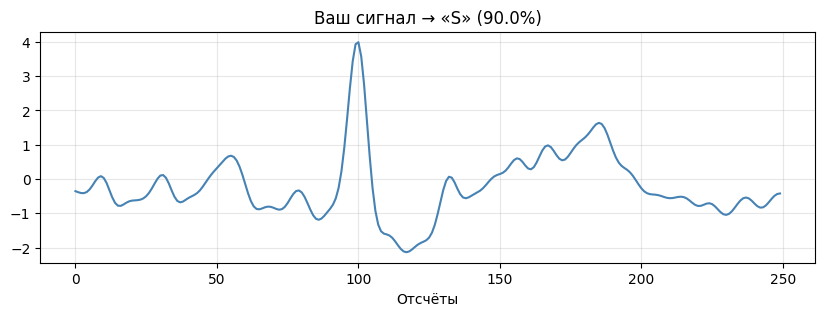

In [140]:
main_test()

In [138]:
def evaluate_labeled_file(file_path='my_ecg.npz', model_path=FINAL_MODEL_PATH, device=None):
    """
    Количественная проверка модели на файле с истинными метками
    (my_ecg.npz с ключами X, rr, y_true).
    Печатает таблицу «истина vs предсказание», accuracy и строит сетку сигналов.
    """
    device = device or get_device()
    model, meta = load_inference_model(model_path, device)
    class_names = meta['class_names']

    data = np.load(file_path)
    X_raw = data['X']
    rr_raw = data['rr'] if 'rr' in data.files else None
    y_true = data['y_true'] if 'y_true' in data.files else None

    X, rr = preprocess_input(X_raw, rr_raw, meta['rr_mean'], meta['rr_std'], meta['rr_clip'])
    preds, probs = predict_signals(model, X, rr, device)

    print('=' * 72)
    print(f'Проверка файла: {file_path} ({len(preds)} сегментов)')
    print('=' * 72)
    print(f"{'#':>3} {'Истина':>7} {'Предсказание':>12} {'Уверенность':>11}  Результат")
    print('-' * 72)
    n_correct = 0
    for i in range(len(preds)):
        true_name = class_names[y_true[i]] if y_true is not None else '—'
        pred_name = class_names[preds[i]]
        conf = probs[i][preds[i]]
        if y_true is not None:
            ok = y_true[i] == preds[i]
            n_correct += ok
            mark = '✓' if ok else '✗'
            print(f'{i + 1:>3} {true_name:>7} {pred_name:>12} {conf:>10.1%}  {mark}')
        else:
            print(f'{i + 1:>3} {true_name:>7} {pred_name:>12} {conf:>10.1%}')
    if y_true is not None:
        print('-' * 72)
        print(f'Accuracy на этом файле: {n_correct}/{len(preds)} = {n_correct / len(preds):.1%}')

    # --- Сетка сигналов: зелёные — верно, красные — ошибки ---
    n = len(preds)
    cols = 4
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 2.5 * rows))
    axes = np.atleast_2d(axes).ravel()
    for i in range(n):
        ax = axes[i]
        true_name = class_names[y_true[i]] if y_true is not None else '?'
        pred_name = class_names[preds[i]]
        ok = y_true is not None and y_true[i] == preds[i]
        color = 'green' if ok else ('red' if y_true is not None else 'steelblue')
        mark = '✓' if ok else ('✗' if y_true is not None else '')
        ax.plot(X[i], color=color, linewidth=1)
        ax.set_title(f'{mark} {true_name} → {pred_name} ({probs[i][preds[i]]:.0%})',
                     fontsize=9,
                     color='darkgreen' if ok else ('darkred' if y_true is not None else 'black'))
        ax.set_xticks([])
        ax.grid(alpha=0.3)
    for j in range(n, len(axes)):
        axes[j].axis('off')
    plt.suptitle(f'{file_path}: истина → предсказание')
    plt.tight_layout()
    plt.show()

    return {'preds': preds, 'probs': probs, 'y_true': y_true}

In [ ]:
# result = evaluate_labeled_file('my_ecg.npz')